In [32]:
import torch
import matplotlib.pyplot as plt
# https://blog.csdn.net/weixin_44841652/article/details/105046519

w是Tensor(张量类型)，Tensor中包含data和grad，data和grad也是Tensor。grad初始为None，调用l.backward()方法后w.grad为Tensor，故更新w.data时需使用w.grad.data。如果w需要计算梯度，那构建的计算图中，跟w相关的tensor都默认需要计算梯度。
https://blog.csdn.net/bit452/article/details/109643481

Tensor 和 tensor的区别 <br>
torch.Tensor()是Python类，更明确的说，是默认张量类型torch.FloatTensor()的别名，torch.Tensor([1,2]) 会调用Tensor类的构造函数__init__，生成单精度浮点类型的张量。<br>
torch.tensor()
torch.tensor()仅仅是Python的函数。函数原型如下
```
torch.tensor(data, dtype=None, device=None, requires_grad=False)
```
其中data可以是：list, tuple, array, scalar等类型。
torch.tensor()可以从data中的数据部分做拷贝（而不是直接引用），根据原始数据类型生成相应的torch.LongTensor。<br>
https://blog.csdn.net/weixin_42788078/article/details/116067067

In [33]:
x_data = [1.0, 2.0, 3.0]
y_data = [4.0, 11.0, 22.0]
''' 
    函数 y = 2 * x ** 2 + x + 1
'''
# 设置变量，计算梯度
w1 = torch.tensor([1.0], requires_grad=True)
w2 = torch.tensor([1.0], requires_grad=True)
b = torch.tensor([1.0], requires_grad=True)

w1_list = []
w2_list = []
b_list = []

# 前馈计算
def forward(x):
    return w1 * x ** 2 + w2 * x + b
# 损失函数
# 构建计算图
def loss(x, y):
    y_pred = forward(x)
    return (y_pred - y) ** 2

print('Predict (before training)',4,forward(4).item())
for epoch in range(100):
    for x, y in zip(x_data, y_data):
        l = loss(x,y)
        l.backward()
        print("\tgrad: ", x,y, w1.item(), w2.item(), b.item())
        w1.data = w1.data - 0.01 * w1.grad.data
        w2.data = w2.data - 0.01 * w2.grad.data
        b.data = b.data - 0.01 * b.grad.data
        # 释放之前计算的梯度
        w1.grad.data.zero_()
        w2.grad.data.zero_()
        b.grad.data.zero_()
        
        w1_list.append(w1.item())
        w2_list.append(w2.item())
        b_list.append(b.item())
        
    print("Epoch: ", epoch, l.item())
print('Predict (after training)',4,forward(4).item())


Predict (before training) 4 21.0
	grad:  1.0 4.0 1.0 1.0 1.0
	grad:  2.0 11.0 1.0199999809265137 1.0199999809265137 1.0199999809265137
	grad:  3.0 22.0 1.3287999629974365 1.174399971961975 1.0972000360488892
Epoch:  0 29.3807430267334
	grad:  1.0 4.0 2.304471969604492 1.4996240139007568 1.2056080102920532
	grad:  2.0 11.0 2.28427791595459 1.4794299602508545 1.1854139566421509
	grad:  3.0 22.0 2.101767063140869 1.3881745338439941 1.1397862434387207
Epoch:  1 4.929345607757568
	grad:  1.0 4.0 1.7021287679672241 1.2549617290496826 1.0953819751739502
	grad:  2.0 11.0 1.7010793685913086 1.253912329673767 1.0943325757980347
	grad:  3.0 22.0 1.7485613822937012 1.2776533365249634 1.1062030792236328
Epoch:  2 1.752403736114502
	grad:  1.0 4.0 1.9868425130844116 1.357080340385437 1.132678747177124
	grad:  2.0 11.0 1.9773105382919312 1.3475483655929565 1.1231467723846436
	grad:  3.0 22.0 1.919111728668213 1.3184489011764526 1.1085970401763916
Epoch:  3 0.11286169290542603
	grad:  1.0 4.0 1.858640

300


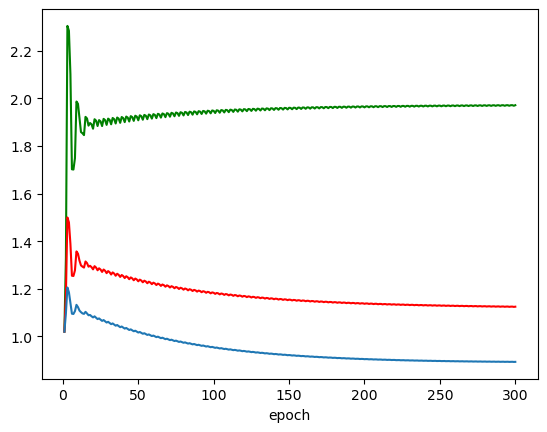

In [34]:
print(len(w1_list))
# https://blog.nowcoder.net/n/747ec9a040254832826343a7f73acfcf
plt.plot(range(1, 301,1), w1_list, "g", label="w1")
plt.plot(range(1, 301,1), w2_list, "r", label="w2")
plt.plot(range(1, 301,1), b_list, label="b")
 
plt.xlabel("epoch")
plt.show()